#Extracción(E - Extract)

In [68]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#Transformación (T - Transform)

##Conoce el conjunto de datos

In [69]:
print("Resumen del Dataset")
df.info()

print("\nTipos de Datos por Columna")
print(df.dtypes)

Resumen del Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

Tipos de Datos por Columna
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


##Comprobación de incoherencias en los datos

In [70]:
print("Valores Nulos")
print(df.isnull().sum())

print("\nFilas Duplicadas")
print(f"Total de duplicados: {df.astype(str).duplicated().sum()}")

columnas_limpias = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, (str, int, float))).all()]

print("\nRevisando inconsistencias en columnas de texto")
for col in columnas_limpias:
    if df[col].dtype == 'object':
        uniquecat = df[col].unique()
        print(f"Columna {col}: {uniquecat[:10]}...")

Valores Nulos
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

Filas Duplicadas
Total de duplicados: 0

Revisando inconsistencias en columnas de texto
Columna customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']...
Columna Churn: ['No' 'Yes' '']...


##Manejo de inconsistencias

In [86]:
df = df.dropna(subset=['Churn'])
df = df[df['Churn'].str.strip() != ''].copy()

df = df.reset_index(drop=True)

cust_df = pd.json_normalize(df['customer']).add_prefix('cust_')
phone_df = pd.json_normalize(df['phone']).add_prefix('phone_')
int_df = pd.json_normalize(df['internet']).add_prefix('net_')
acc_df = pd.json_normalize(df['account']).add_prefix('acc_')

df_flat = pd.concat([
    df.drop(['customer', 'phone', 'internet', 'account'], axis=1),
    cust_df, phone_df, int_df, acc_df
], axis=1)

print(df_flat['Churn'].tail())

7038     No
7039    Yes
7040     No
7041     No
7042     No
Name: Churn, dtype: object


##Columna de cuentas diarias (Opcional)

In [87]:
df_flat['acc_Charges.Monthly'] = pd.to_numeric(df_flat['acc_Charges.Monthly'], errors='coerce')

df_flat['Cuentas_Diarias'] = (df_flat['acc_Charges.Monthly'] / 30).round(2)

print("Nueva columna creada")
print(df_flat[['acc_Charges.Monthly', 'Cuentas_Diarias']].head())

Nueva columna creada
   acc_Charges.Monthly  Cuentas_Diarias
0                 65.6             2.19
1                 59.9             2.00
2                 73.9             2.46
3                 98.0             3.27
4                 83.9             2.80


##Estandarización y transformación de datos (opcional)

In [88]:
# Solución "Blindada"
# No importa si es Yes, yes, YES o " Yes ", esto lo arregla todo:
df_flat['Churn'] = df_flat['Churn'].astype(str).str.strip().str.capitalize()
diccionario_binario = {'Yes': 1, 'No': 0}
df_flat['Churn'] = df_flat['Churn'].map(diccionario_binario)

print("--- Conteo de Churn (1 = Se fue, 0 = Se quedó) ---")
print(df_flat['Churn'].value_counts())

nuevos_nombres = {
    'cust_gender': 'Género',
    'cust_SeniorCitizen': 'Adulto_Mayor',
    'cust_Partner': 'Socio',
    'cust_Dependents': 'Dependientes',
    'phone_PhoneService': 'Servicio_Telefonico',
    'net_InternetService': 'Tipo_Internet',
    'acc_Contract': 'Tipo_Contrato',
    'acc_Charges.Monthly': 'Cargos_Mensuales_Total',
    'cust_tenure': 'Meses_Antiguedad'
}

df_flat = df_flat.rename(columns=nuevos_nombres)

print("\nNuevas columnas estandarizadas:")
print(df_flat.columns.tolist())

--- Conteo de Churn (1 = Se fue, 0 = Se quedó) ---
Churn
0    5174
1    1869
Name: count, dtype: int64

Nuevas columnas estandarizadas:
['customerID', 'Churn', 'Género', 'Adulto_Mayor', 'Socio', 'Dependientes', 'Meses_Antiguedad', 'Servicio_Telefonico', 'phone_MultipleLines', 'Tipo_Internet', 'net_OnlineSecurity', 'net_OnlineBackup', 'net_DeviceProtection', 'net_TechSupport', 'net_StreamingTV', 'net_StreamingMovies', 'Tipo_Contrato', 'acc_PaperlessBilling', 'acc_PaymentMethod', 'Cargos_Mensuales_Total', 'acc_Charges.Total', 'Cuentas_Diarias']


#Carga y análisis(L - Load & Analysis)

##Análisis Descriptivo

In [89]:
print("")
print(df_flat['Churn'].head(10))

print("\n--- Conteo de categorías actuales ---")
print(df_flat['Churn'].value_counts(dropna=False))

print(f"\nTipo de dato de la columna: {df_flat['Churn'].dtype}")

resumen_stats = df_flat.describe().round(2)

print("Análisis Descriptivo de Variables Numéricas")
print(resumen_stats)

print("\nPromedios comparativos: Se quedan (0) vs Se van (1)")

columnas_interes = ['Meses_Antiguedad', 'Cargos_Mensuales_Total', 'Cuentas_Diarias', 'Churn']
comparativa = df_flat[columnas_interes].groupby('Churn').mean().round(2)

print(comparativa)


0    0
1    0
2    1
3    1
4    1
5    0
6    0
7    0
8    0
9    0
Name: Churn, dtype: int64

--- Conteo de categorías actuales ---
Churn
0    5174
1    1869
Name: count, dtype: int64

Tipo de dato de la columna: int64
Análisis Descriptivo de Variables Numéricas
         Churn  Adulto_Mayor  Meses_Antiguedad  Cargos_Mensuales_Total  \
count  7043.00       7043.00           7043.00                 7043.00   
mean      0.27          0.16             32.37                   64.76   
std       0.44          0.37             24.56                   30.09   
min       0.00          0.00              0.00                   18.25   
25%       0.00          0.00              9.00                   35.50   
50%       0.00          0.00             29.00                   70.35   
75%       1.00          0.00             55.00                   89.85   
max       1.00          1.00             72.00                  118.75   

       Cuentas_Diarias  
count          7043.00  
mean            

##Distribución de evasión

Gráfico de barras


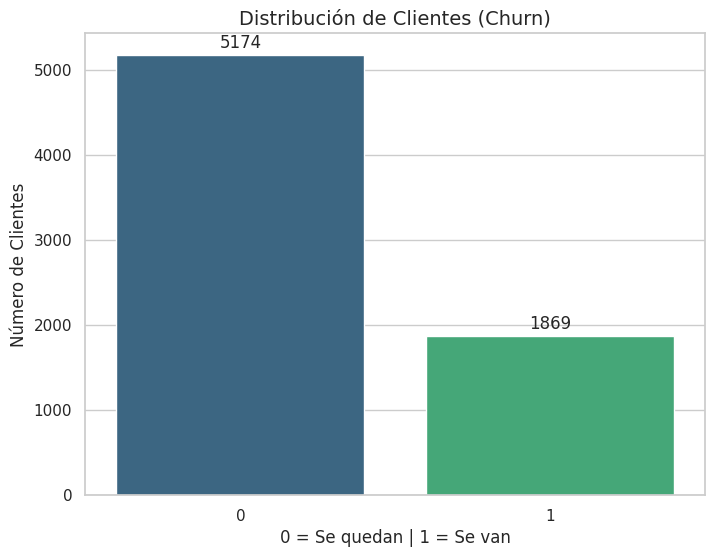

--- Porcentaje de Distribución ---
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Histograma comparativo


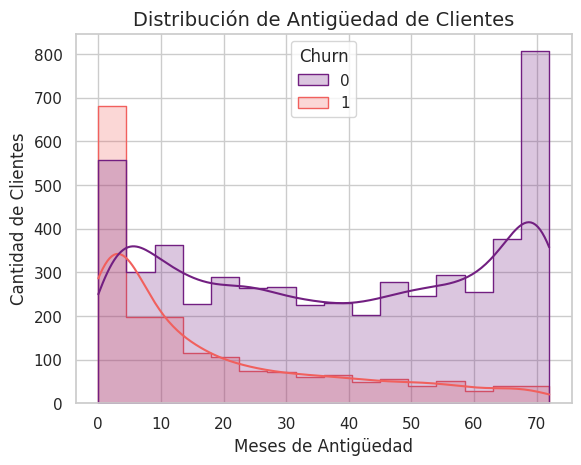

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Gráfico de barras")
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='Churn', data=df_flat, hue='Churn', palette='viridis', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('Distribución de Clientes (Churn)', fontsize=14)
plt.xlabel('0 = Se quedan | 1 = Se van', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

plt.show()

tasa_churn = (df_flat['Churn'].value_counts(normalize=True) * 100).round(2)
print("--- Porcentaje de Distribución ---")
print(tasa_churn)

print("\nHistograma comparativo")
sns.histplot(data=df_flat, x='Meses_Antiguedad', hue='Churn', kde=True, element="step", palette='magma')

plt.title('Distribución de Antigüedad de Clientes', fontsize=14)
plt.xlabel('Meses de Antigüedad', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

plt.show()

##Recuento de evasión por variables categóricas

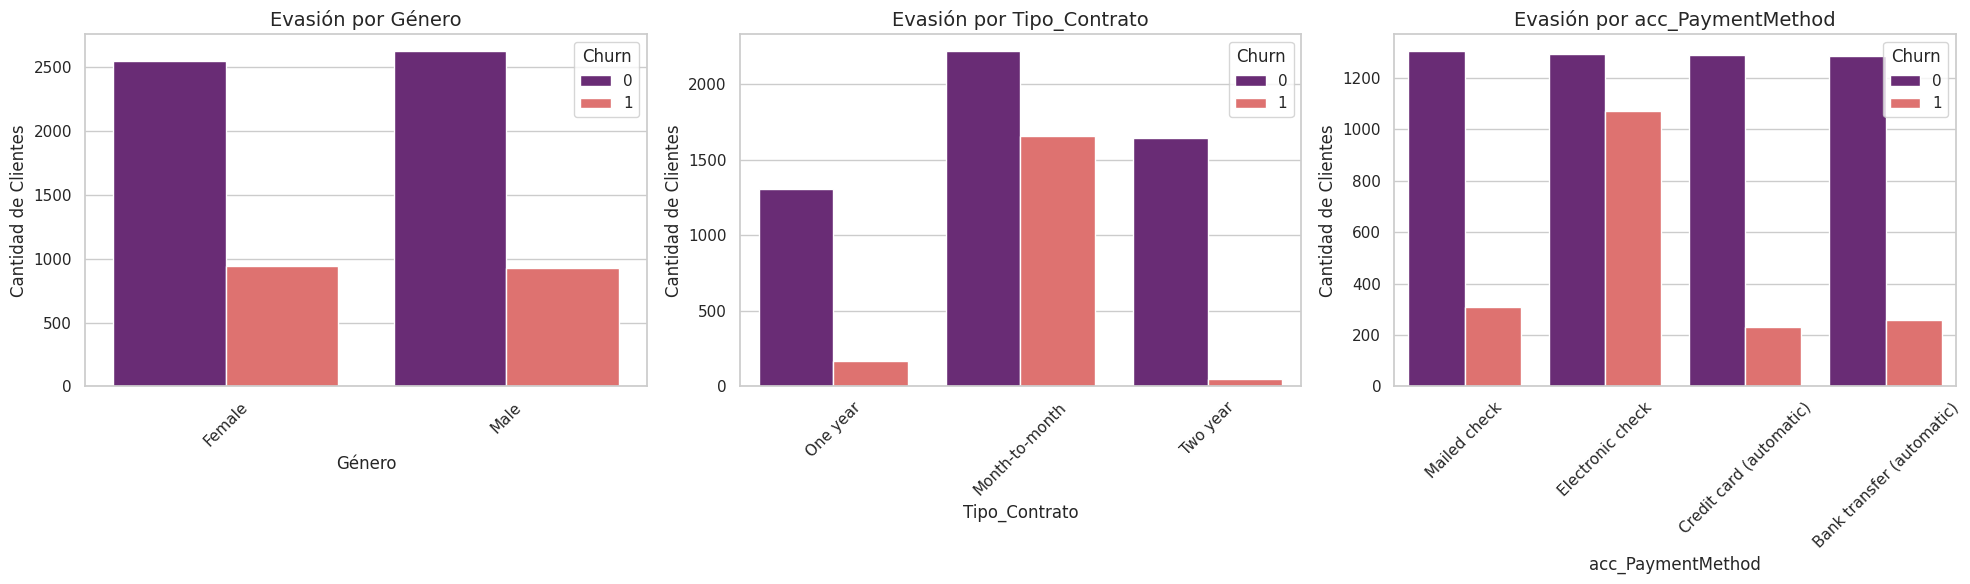

--- Porcentaje de Evasión por Categoría ---

Distribución en Género:
Género
Female    27.0
Male      26.0
Name: Churn, dtype: float64

Distribución en Tipo_Contrato:
Tipo_Contrato
Month-to-month    43.0
One year          11.0
Two year           3.0
Name: Churn, dtype: float64

Distribución en acc_PaymentMethod:
acc_PaymentMethod
Bank transfer (automatic)    17.0
Credit card (automatic)      15.0
Electronic check             45.0
Mailed check                 19.0
Name: Churn, dtype: float64


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_cat = ['Género', 'Tipo_Contrato', 'acc_PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, var in enumerate(variables_cat):
    if var in df_flat.columns:
        sns.countplot(data=df_flat, x=var, hue='Churn', palette='magma', ax=axes[i])
        axes[i].set_title(f'Evasión por {var}', fontsize=14)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Cantidad de Clientes')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("--- Porcentaje de Evasión por Categoría ---")
for var in variables_cat:
    if var in df_flat.columns:
        print(f"\nDistribución en {var}:")
        print(df_flat.groupby(var)['Churn'].mean().round(2) * 100)

##Conteo de evasión por variables numéricas

/tmp/ipykernel_598/183003999.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Meses_Antiguedad', data=df_flat, palette='Set2', ax=axes[0])
/tmp/ipykernel_598/183003999.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Cargos_Mensuales_Total', data=df_flat, palette='Set1', ax=axes[1])


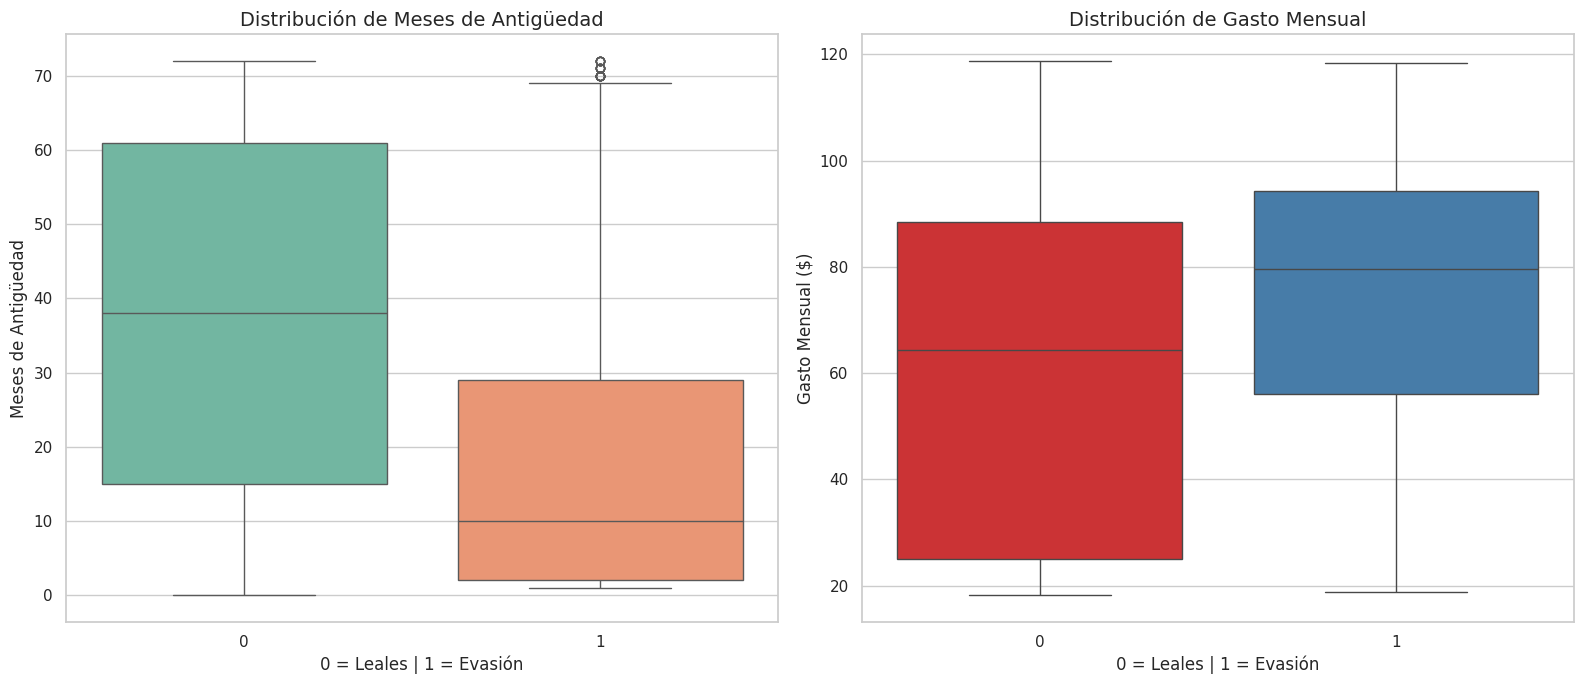

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(x='Churn', y='Meses_Antiguedad', data=df_flat, palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de Meses de Antigüedad', fontsize=14)
axes[0].set_xlabel('0 = Leales | 1 = Evasión')
axes[0].set_ylabel('Meses de Antigüedad')

sns.boxplot(x='Churn', y='Cargos_Mensuales_Total', data=df_flat, palette='Set1', ax=axes[1])
axes[1].set_title('Distribución de Gasto Mensual', fontsize=14)
axes[1].set_xlabel('0 = Leales | 1 = Evasión')
axes[1].set_ylabel('Gasto Mensual ($)')

plt.tight_layout()
plt.show()

#Informe Final
##1. Introducción
El objetivo de este análisis fue identificar los patrones de comportamiento de los clientes de Telecom X para entender las razones detrás de la evasión (Churn). Se procesó un conjunto de datos crudos en formato JSON, realizando limpieza, transformación y análisis descriptivo.

##2. Metodología
-Limpieza de Datos: Se eliminaron registros con valores vacíos en la variable objetivo y se normalizaron las categorías de texto.

-Feature Engineering: Se creó la variable Cuentas_Diarias (Cargo Mensual / 30) para analizar el impacto del gasto diario percibido.

-Estandarización: Se convirtieron variables categóricas a formatos binarios (0 y 1) para facilitar el análisis estadístico.

##3. Hallazgos Principales (Insights)
De acuerdo con el análisis descriptivo realizado, se observaron los siguientes patrones:

###A. Perfil Financiero y de Antigüedad

Las variables numéricas revelan diferencias críticas entre ambos grupos:

-Gasto Mensual: Los clientes que abandonan la empresa tienen un promedio de cargos más alto (74) que los clientes leales (61). Esto indica que el costo es un factor de presión.

-Fidelidad: Existe una brecha clara. Los clientes leales promedian 37 meses, mientras que los que se van promedian solo 18 meses.

###B. Análisis por Variables Categóricas
Al explorar las dimensiones cualitativas, se identificaron los verdaderos factores de riesgo:

-Tipo de Contrato: Existe una correlación directa entre el contrato "Mes a Mes" y la alta tasa de evasión, en comparación con los contratos anuales o bianuales.

-Método de Pago: Los clientes con métodos de pago manuales (como cheque electrónico) tienden a evadir más que aquellos con cargos automáticos a tarjeta o cuenta bancaria.

-Género: No se detectó una diferencia estadísticamente relevante entre géneros, lo que indica que la estrategia de retención no necesita ser segmentada por este factor.

###C. Análisis de Distribución y Comportamiento del Gasto

Al profundizar en la distribución de los datos más allá de los promedios, los gráficos de cajas y dispersión revelan detalles críticos:

-Identificación de la Ventana de Riesgo: La evasión no es constante; se concentra fuertemente en clientes nuevos (primeros 18-24 meses). Superar esta barrera temporal aumenta drásticamente la probabilidad de permanencia.

-Impacto del Alto Consumo: Los gráficos de cajas confirman que el grupo de evasión está compuesto por clientes con facturaciones superiores al promedio, lo que sugiere que son más sensibles a ofertas de la competencia o fallas en el servicio.

##4. Conclusiones y Recomendaciones
Migración de Contratos: Incentivar el paso de clientes de "Mes a Mes" a contratos de "1 Año" mediante descuentos o beneficios adicionales, ya que la estabilidad contractual es el mayor freno para la evasión.

Automatización de Pagos: Promover el registro de métodos de pago automáticos para reducir la fricción en el proceso de facturación mensual.

Calidad del Servicio: Dado que el precio no es el diferenciador, se recomienda realizar encuestas de satisfacción técnica, ya que la fuga podría deberse a la calidad de la conexión o soporte.

Fidelización Temprana: Dado que la fuga ocurre mayoritariamente cerca de los 18 meses, las campañas de retención deben activarse antes de cumplir el primer año para asegurar que el cliente cruce el umbral de estabilidad.

Gestión de Clientes de Alto Valor: Es prioritario monitorear a los clientes con cargos mensuales altos, ya que, al ser los que más pagan, son los más propensos a abandonar la compañía si no perciben un valor proporcional al costo.